# Required assignment 9.1 Coding your decision trees

In this notebook, you’ll build a decision tree classifier using a real-world data set in Python. The workflow starts with thorough data preprocessing, followed by model training, evaluation and visualisation. You’ll then impute additional data sets to further test the classifier and analyse the resulting confusion matrix.

In [1]:
### Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.tree import plot_tree


The [Telco Customer Churn](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset) data set contains information about 7,043 customers of a fictional telecommunications company, including demographics, account details, services subscribed and whether the customer has churned or not. This data set is widely used for building predictive models to identify customers at risk of leaving, enabling organisations to develop effective retention strategies.

In [2]:
df = pd.read_csv('data/Telco_customer_churn.csv')

In [13]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [7]:
df.isna().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

## Data preprocessing

When building a machine learning model to predict customer churn (or a similar outcome), not all columns in the data set are useful. Some should be excluded because they serve as unique identifiers, are redundant, are overly granular or are directly related to the target variable. For example, columns such as `CustomerID`, `City`, `State`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`, `Churn Label`, `Churn Score`, and `Churn Reason` can be dropped, as they either provide limited predictive value or leak information about the outcome.

### Question 1

Drop the columns listed in `columns_to_drop` from the data set `df`, and store the resulting data frame in `df_cleaned`.

In [15]:
### GRADED CELL
columns_to_drop = [
    'CustomerID', 'City', 'State', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'Churn Reason'
]
df_cleaned = df.drop(columns_to_drop, axis=1)
# Display the remaining columns
print("Remaining columns:")
print(df_cleaned.columns)

Remaining columns:
Index(['Count', 'Country', 'Gender', 'Senior Citizen', 'Partner', 'Dependents',
       'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV'],
      dtype='str')


### Question 2

The target is `Churn Value`.
Find the unique values of `Churn Value` and assign it to `ans2`.

In [17]:
### GRADED

ans2 = df['Churn Value'].unique()

print("The unique values of `Churn Value` is given by")
print(ans2)


The unique values of `Churn Value` is given by
[1 0]


The first step in data preprocessing is to remove columns that are not relevant for model building. 

Next, you eliminate features that have little correlation with the target variable. To do this, you’ll first explore some of the columns and select the most appropriate ones by choosing a mix of numeric and non-numeric features.

Let’s begin by separating the target variable from the input features.

In [ ]:
df_cleaned.columns


### Question 3

From the `df_cleaned` data set, separate the input features and the target variable `Churn Value`:

- Drop the `Churn Value` from the input features in the `df_cleaned`data set and store the features in `X`.

- Store the target `Churn Value` in the output `y`.

In [18]:
### GRADED CELL
X = df_cleaned.drop('Churn Value', axis=1)
y = df_cleaned['Churn Value']
### Answer Test

print(X.shape)
print(y.shape)


(7043, 22)
(7043,)


The features in `selected_features` are chosen for their relevance to churn behaviour. They reflect customer relationship duration, payment and contract flexibility, service usage and demographic risk factors. These factors are commonly linked to churn in both research and industry practice.

The `selected_features` has both numeric and categorical features.

### Question 4

- Separate the numeric and categorical features.

- Encode the categorical features (use `get_dummies` for one-hot encoding).

- Concatenate the numeric and encoded categorical features.

Note: `Tenure Months` and `Total Charges` are the only numeric features.

In [19]:
### GRADED CELL

selected_features = [
    'Tenure Months', 'Total Charges', 'Contract',
    'Payment Method', 'Paperless Billing', 'Internet Service',
   'Tech Support', 'Streaming TV', 'Streaming Movies', 'Senior Citizen', 'Gender'
    ]
numeric_features = ['Tenure Months', 'Total Charges']
categorical_features = [feature for feature in selected_features if feature not in numeric_features]
df_numeric = X[numeric_features].apply(pd.to_numeric, errors='coerce')
df_categorical = pd.get_dummies(X[categorical_features], dtype=int)
X = pd.concat([df_numeric, df_categorical], axis=1)
# Answer Test
print(X.shape)


(7043, 27)


In [22]:
X.replace(r'^\s*$', np.nan, regex=True, inplace=True)
X = X.infer_objects()
X.fillna(0, inplace=True)
X = X.apply(pd.to_numeric)

### Question 5

- Use `train_test_split` from `sklearn.model_selection` and split the data into`X_train`,`X_test`,`y_train`,`y_test`. Use 20 per cent as the `test_size`.

- Model a `DecisionTreeClassifier` and store the model in `clf`.

- Fit the model and compute `y_pred` using the `.predict()` function.

In [23]:
### GRADED CELL
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
# Answer test
print(y_pred)


[1 0 0 ... 1 0 0]


### Question 6

- Compute the `confusion_matrix` using the `y_test` and `y_pred` functions.

- Compute the accuracy.

In [1]:
### GRADED CELL
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Answer test

print("Confusion Matrix:\n", cm)

print(f"Accuracy: {accuracy:.2f}")


NameError: name 'confusion_matrix' is not defined

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Pre-pruned decision tree (limits depth and leaf size)
clf_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,           # Limit tree depth
    min_samples_leaf=5,    # Minimum samples per leaf
    max_leaf_nodes=10,     # Maximum number of leaf nodes
    random_state=42
)
clf_pruned.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at th

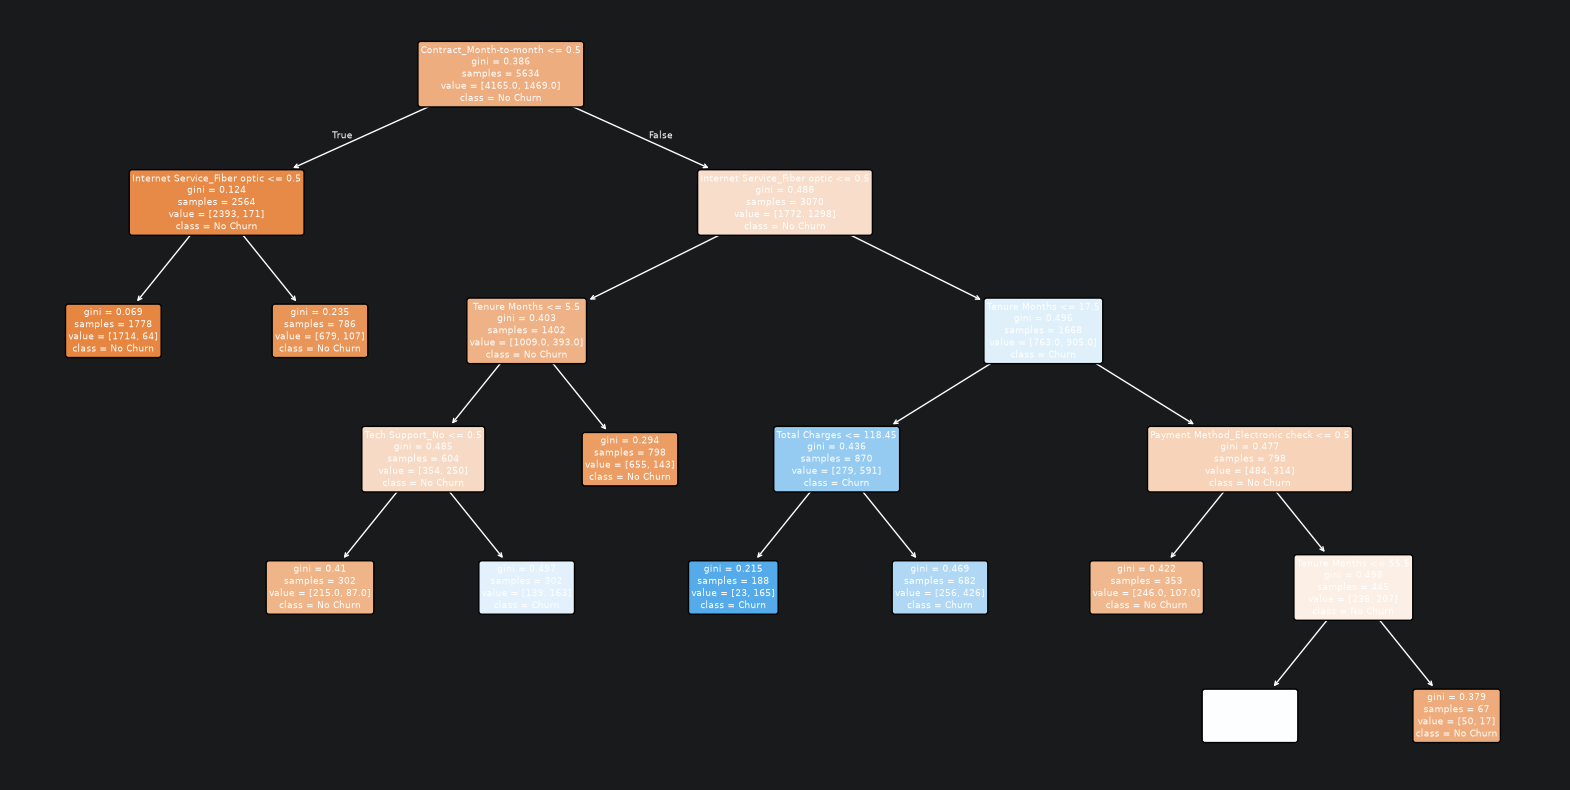

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # Adjust size as needed
plot_tree(
    clf_pruned,
    feature_names=X_train.columns,         # Use your feature names
    class_names=['No Churn', 'Churn'],     # Adjust if your target classes are different
    filled=True,
    rounded=True
)
plt.show()


By applying pre-pruning techniques and visualising the resulting tree, this approach strikes a balance between interpretability and performance, keeping the decision tree both understandable and less prone to overfitting.